In [2]:
from torch.utils.data import Dataset, DataLoader
import numpy as np 
import torch 
import os 
data_path = os.path.join('data','UBFC-RPPG-Dataset')
subjects = os.listdir(data_path)  

In [3]:
sample_subject = subjects[0]
sample_roi = np.loadtxt(os.path.join(data_path, sample_subject, 'roi_colors.txt'), delimiter=',')
sample_roi.shape 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

In [4]:
sample_signal = np.loadtxt(os.path.join(data_path, sample_subject, 'ground_truth.txt'))

In [5]:
#each frame has 3 labels in the dataset : Normalized Blood Volume Pulse , Heart Rate and Time. We will only train on the first one


class UBFC_Dataset(Dataset):
    def __init__(self, data_path, subjects,seq_len=10):
        self.data_path = data_path 
        self.subjects = subjects 
        self.seq_len = seq_len
        self.possible_ranges = []
        for subject in subjects:
            signal_path = os.path.join(data_path,subject, 'ground_truth.txt')
            signal = np.loadtxt(signal_path)
            num_starts = signal.shape[-1] - seq_len 
            for i in range(num_starts): 
                self.possible_ranges.append((subject, i)) 
    def __len__(self):
        return len(self.possible_ranges)

    def __getitem__(self, index):
        subject,i = self.possible_ranges[index]
        signal_path = os.path.join(self.data_path,subject, 'ground_truth.txt')
        colors_path = os.path.join(self.data_path, subject, 'roi_colors.txt')
        signals = np.loadtxt(signal_path)
        colors = np.loadtxt(colors_path, delimiter=',')
        signal_seq = signals[0,i : i + self.seq_len]
        color_seq = colors[i : i + self.seq_len]


        # --- MADE A BIG MISTAKE OF JUST NORMALIZING BY DIVIDING BY 255 AND THAT WAS CAUSING SATURATION
        
        min_vals = color_seq.min(axis=0, keepdims=True)
        max_vals = color_seq.max(axis=0, keepdims=True)
        color_seq = (color_seq - min_vals) / (max_vals - min_vals + 1e-6)
        # -------------------------------
        return torch.tensor(color_seq, dtype=torch.float32), torch.tensor(signal_seq, dtype=torch.float32)


In [6]:
batch_size = 256
seq_len = 128
dataset = UBFC_Dataset(data_path, subjects,seq_len=seq_len)

from  torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size 
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle=False)

sample_color_seq, sample_signal_seq = dataset[0]
print(sample_color_seq.shape) 

torch.Size([128, 9])


In [7]:
class LSTMModel(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers,batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, output_size) 
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        output = self.fc(lstm_out)  
        return output  

In [ ]:
log_every = 10
num_epochs = 10 
val_every = 100

check_point_pth = os.path.join('checkpoints', 'best_model.pth')
prev_best_val_loss = float('inf')
def save_checkpoint(model, optimizer, epoch, step, loss, path):
    checkpoint = {
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'epoch':epoch,
        'step':step,
        'loss':loss
    }
    torch.save(checkpoint, path)

model = LSTMModel(input_size=9, hidden_size=64, num_layers=2, output_size=1)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = torch.nn.MSELoss() 
num_params = sum([param.numel() for param in model.parameters()])

print(f"Training  a  {num_params} parameters model on device: {device}")
def val():
    model.eval()
    total_loss = 0
    for i,(color_seq, signal_seq) in enumerate(test_loader):
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq)
        loss = criterion(predictions.flatten(),signal_seq.flatten())
        total_loss += loss.item()
    model.train()
    return total_loss/len(test_loader)


for epoch in range(num_epochs):
    model.train()
    total_loss = 0  
    for i, (color_seq, signal_seq) in enumerate(train_loader):
        optimizer.zero_grad()
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq) 
        loss = criterion(predictions.flatten(), signal_seq.flatten())
        loss.backward()
        optimizer.step() 
        if (i+1) % log_every == 0:
            
            if (i+1) % val_every ==0:
                val_loss = val()
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], train Loss: {loss.item():.4f}, val Loss: {val_loss:.4f}") 
                if val_loss < prev_best_val_loss:
                    print(f"New best model 💫💫 found.   loss: {val_loss:.4f}")  
                    save_checkpoint(model, optimizer, epoch, i, val_loss, check_point_pth)
                    prev_best_val_loss = val_loss
            else: 
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], train Loss: {loss.item():.4f}")

Epoch [1/10], Step [10/476], train Loss: 1.0035
Epoch [1/10], Step [20/476], train Loss: 1.0344
Epoch [1/10], Step [30/476], train Loss: 1.0242
Epoch [1/10], Step [40/476], train Loss: 0.9361
Epoch [1/10], Step [50/476], train Loss: 0.8560
Epoch [1/10], Step [60/476], train Loss: 0.8321
Epoch [1/10], Step [70/476], train Loss: 0.8043
Epoch [1/10], Step [80/476], train Loss: 0.7440
Epoch [1/10], Step [90/476], train Loss: 0.7676
Epoch [1/10], Step [100/476], train Loss: 0.6594, val Loss: 0.6657
New best model 💫💫 found.   loss: 0.6657
Epoch [1/10], Step [110/476], train Loss: 0.7030
Epoch [1/10], Step [120/476], train Loss: 0.6150
Epoch [1/10], Step [130/476], train Loss: 0.6397
Epoch [1/10], Step [140/476], train Loss: 0.6694
Epoch [1/10], Step [150/476], train Loss: 0.5607
Epoch [1/10], Step [160/476], train Loss: 0.5548
Epoch [1/10], Step [170/476], train Loss: 0.5761
Epoch [1/10], Step [180/476], train Loss: 0.5734
Epoch [1/10], Step [190/476], train Loss: 0.5557
Epoch [1/10], Step [

In [9]:

def test(model):
    model.eval()
    
    color_seq, signal_seq = next(iter(test_loader))
    color_seq = color_seq.to(device)
    signal_seq = signal_seq.to(device)
    predictions = model(color_seq)
        
    return predictions[0], signal_seq[0] 
       
        


# preds , sign = test()


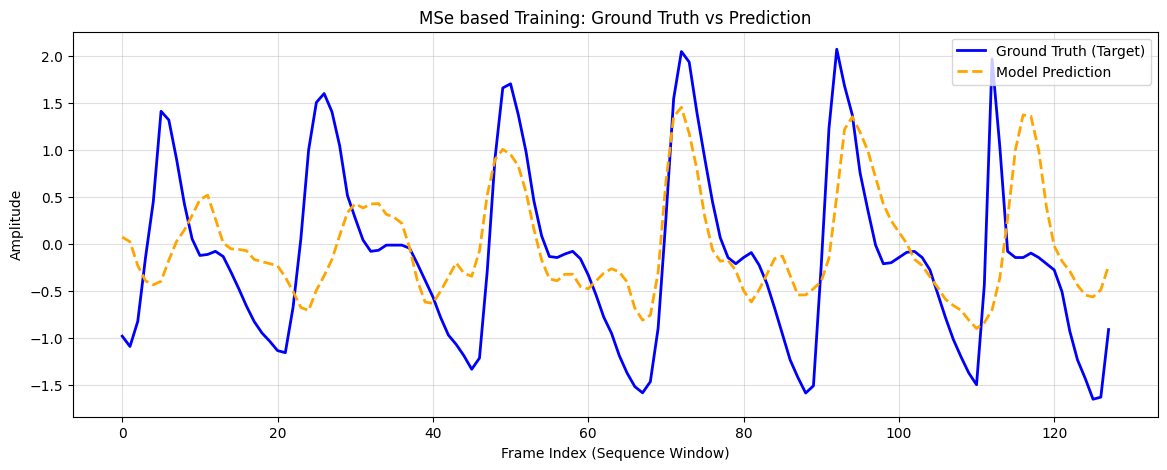

In [55]:
import matplotlib.pyplot as plt


preds, sign = test()


preds_np = preds.detach().cpu().numpy()
sign_np = sign.detach().cpu().numpy()

plt.figure(figsize=(14, 5))


plt.plot(sign_np, label='Ground Truth (Target)', color='blue', linewidth=2)
plt.plot(preds_np, label='Model Prediction', color='orange', linewidth=2, linestyle='--')

plt.title('MSe based Training: Ground Truth vs Prediction')
plt.xlabel('Frame Index (Sequence Window)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)


plt.savefig('mse_version.png')
# Show the plot
plt.show()

In [ ]:
#Detected Heartbeats - Ground Truth: 6, Model Prediction: 5

# MSe based training is not the best way to train a model for rPPG signal prediction. The model is being heavily penalized for small phase shifts in the prediction, which is not idea for this task. 

# This is very bad because it heavily relies on perfect alignment of the predicted signal with the ground truth. This is practically impossible to achieve because of random errors in measurement, noise and other factors.

#so we need to switch to a loss function that judged the model on how well it captures the rythm and pattern of the signal rather than the exact alignment and values.



(75, 90)

In [58]:
#another version with only one change of using Negative Pearson Correlation Coefficient as the loss function instead of MSE.

log_every = 10
num_epochs = 10 
val_every = 100

check_point_pth = os.path.join('checkpoints', 'best_model_pearson.pth')
prev_best_val_loss = float('inf')
def save_checkpoint(model, optimizer, epoch, step, loss, path):
    checkpoint = {
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'epoch':epoch,
        'step':step,
        'loss':loss
    }
    torch.save(checkpoint, path)

model = LSTMModel(input_size=9, hidden_size=64, num_layers=2, output_size=1)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


class NegPearsonLoss(torch.nn.Module):
    def forward(self, preds, target):
        preds = preds - torch.mean(preds)
        target = target - torch.mean(target)
        numerator = torch.sum(preds * target)
        denominator = torch.sqrt(torch.sum(preds ** 2)) * torch.sqrt(torch.sum(target ** 2))
        pearson_corr = numerator / (denominator + 1e-8)
        return 1 - pearson_corr 

criterion = NegPearsonLoss()
num_params = sum([param.numel() for param in model.parameters()])

print(f"Training a  {num_params} parameters model on device: {device}")
def val():
    model.eval()
    total_loss = 0
    for i,(color_seq, signal_seq) in enumerate(test_loader):
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq)
        loss = criterion(predictions.flatten(),signal_seq.flatten())
        total_loss += loss.item()
    model.train()
    return total_loss/len(test_loader)


for epoch in range(num_epochs):
    model.train()
    total_loss = 0  
    for i, (color_seq, signal_seq) in enumerate(train_loader):
        optimizer.zero_grad()
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq) 
        loss = criterion(predictions.flatten(), signal_seq.flatten())
        loss.backward()
        optimizer.step() 
        if (i+1) % log_every == 0:
            
            if (i+1) % val_every ==0:
                val_loss = val()
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], train Loss: {loss.item():.4f}, val Loss: {val_loss:.4f}") 
                if val_loss < prev_best_val_loss:
                    print(f"New best model 💫💫 found.   loss: {val_loss:.4f}")  
                    save_checkpoint(model, optimizer, epoch, i, val_loss, check_point_pth)
                    prev_best_val_loss = val_loss
            else: 
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], train Loss: {loss.item():.4f}")

Training a  52545 parameters model on device: cuda


Epoch [1/10], Step [10/476], train Loss: 0.6507
Epoch [1/10], Step [20/476], train Loss: 0.5756
Epoch [1/10], Step [30/476], train Loss: 0.5187
Epoch [1/10], Step [40/476], train Loss: 0.4737
Epoch [1/10], Step [50/476], train Loss: 0.4293
Epoch [1/10], Step [60/476], train Loss: 0.4145
Epoch [1/10], Step [70/476], train Loss: 0.4193
Epoch [1/10], Step [80/476], train Loss: 0.4118
Epoch [1/10], Step [90/476], train Loss: 0.4224
Epoch [1/10], Step [100/476], train Loss: 0.4231, val Loss: 0.4091
New best model 💫💫 found.   loss: 0.4091
Epoch [1/10], Step [110/476], train Loss: 0.4228
Epoch [1/10], Step [120/476], train Loss: 0.4117
Epoch [1/10], Step [130/476], train Loss: 0.4335
Epoch [1/10], Step [140/476], train Loss: 0.4089
Epoch [1/10], Step [150/476], train Loss: 0.3986
Epoch [1/10], Step [160/476], train Loss: 0.3844
Epoch [1/10], Step [170/476], train Loss: 0.4171
Epoch [1/10], Step [180/476], train Loss: 0.3800
Epoch [1/10], Step [190/476], train Loss: 0.4188
Epoch [1/10], Step [

KeyboardInterrupt: 

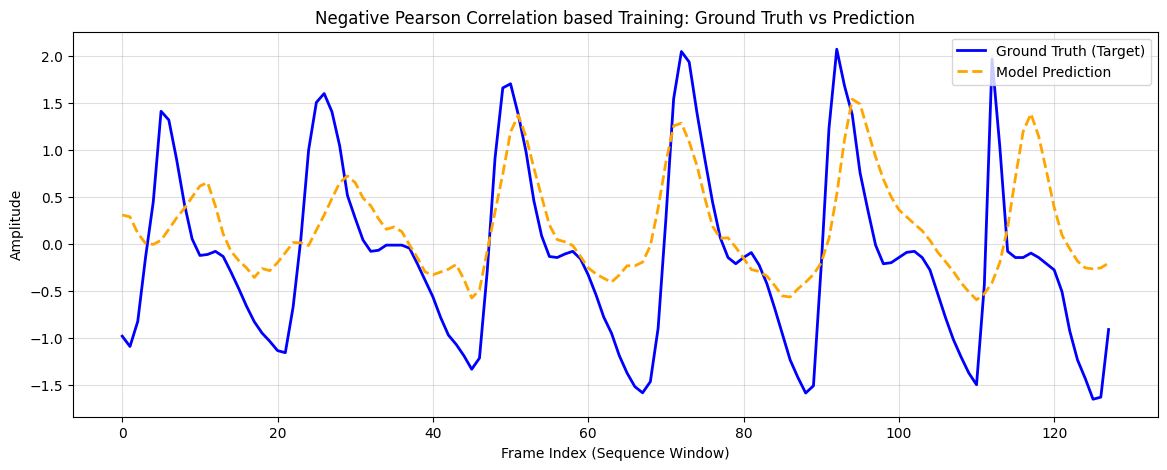

In [61]:
import matplotlib.pyplot as plt


preds, sign = test()


preds_np = preds.detach().cpu().numpy()
preds_np = preds_np*10
sign_np = sign.detach().cpu().numpy()

plt.figure(figsize=(14, 5))


plt.plot(sign_np, label='Ground Truth (Target)', color='blue', linewidth=2)
plt.plot(preds_np, label='Model Prediction', color='orange', linewidth=2, linestyle='--')

plt.title('Negative Pearson Correlation based Training: Ground Truth vs Prediction')
plt.xlabel('Frame Index (Sequence Window)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)


plt.savefig('neg_pearson_version.png')
# Show the plot
plt.show()

In [ ]:
#next level up : We have to use bidirectional LSTMs and also join the pearson and mse losses

class LSTMModel(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers,batch_first=True,bidirectional=True)
        self.fc = torch.nn.Linear(hidden_size*2, output_size) 
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        output = self.fc(lstm_out)  
        return output  







In [ ]:
#another version with only one change of using Negative Pearson Correlation Coefficient as the loss function instead of MSE.

check_point_pth = os.path.join('checkpoints', 'best_model_bidirectional_joint_loss.pth')
prev_best_val_loss = float('inf')


log_every = 10
num_epochs = 10 
val_every = 100


def save_checkpoint(model, optimizer, epoch, step, loss, path):
    checkpoint = {
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'epoch':epoch,
        'step':step,
        'loss':loss
    }
    torch.save(checkpoint, path)

model = LSTMModel(input_size=9, hidden_size=64, num_layers=2, output_size=1)



model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

if os.path.exists(check_point_pth):
    checkpoint = torch.load(check_point_pth)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    

In [22]:

class HybridRPPGLoss(torch.nn.Module):
    def forward(self, preds, target,alpha=1.0):
        preds = preds - torch.mean(preds)
        target = target - torch.mean(target)
        numerator = torch.sum(preds * target)
        denominator = torch.sqrt(torch.sum(preds ** 2)) * torch.sqrt(torch.sum(target ** 2))
        pearson_corr = numerator / (denominator + 1e-8)
        pearson_loss = 1 - pearson_corr


        mse = torch.nn.MSELoss()
        mse_loss = mse(preds,target)
        return  pearson_loss,mse_loss, pearson_loss + alpha * mse_loss

criterion = HybridRPPGLoss()
num_params = sum([param.numel() for param in model.parameters()])

print(f"Training a  {num_params} parameters bidirectional LSTM with hybrid loss  on device: {device}")
def val():
    model.eval()
    total_loss = 0
    for i,(color_seq, signal_seq) in enumerate(test_loader):
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq)
        _,_,loss = criterion(predictions.flatten(),signal_seq.flatten())
        total_loss += loss.item()
    model.train()
    return total_loss/len(test_loader)




Training a  52545 parameters bidirectional LSTM with hybrid loss  on device: cuda


In [ ]:

for epoch in range(num_epochs):
    model.train()
    total_loss = 0  
    for i, (color_seq, signal_seq) in enumerate(train_loader):
        optimizer.zero_grad()
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq) 
        pearson_loss,mse_loss,loss = criterion(predictions.flatten(), signal_seq.flatten())
        loss.backward()
        optimizer.step() 
        if (i+1) % log_every == 0:
            
            if (i+1) % val_every ==0:
                val_loss = val()
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], train Loss: {loss.item():.4f}, val Loss: {val_loss:.4f}") 
                if val_loss < prev_best_val_loss:
                    print(f"New best model 💫💫 found.   loss: {val_loss:.4f}")  
                    save_checkpoint(model, optimizer, epoch, i, val_loss, check_point_pth)
                    prev_best_val_loss = val_loss
            else: 
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Pearson train Loss: {pearson_loss.item():.4f} MSE train Loss: {mse_loss.item():.4f}")

Training a  52545 parameters bidirectional LSTM with hybrid loss  on device: cuda


Epoch [1/10], Step [10/238], Pearson train Loss: 0.2525 MSE train Loss: 0.4491
Epoch [1/10], Step [20/238], Pearson train Loss: 0.2634 MSE train Loss: 0.4824
Epoch [1/10], Step [30/238], Pearson train Loss: 0.2792 MSE train Loss: 0.4872
Epoch [1/10], Step [40/238], Pearson train Loss: 0.2516 MSE train Loss: 0.4555
Epoch [1/10], Step [50/238], Pearson train Loss: 0.2352 MSE train Loss: 0.4144
Epoch [1/10], Step [60/238], Pearson train Loss: 0.2570 MSE train Loss: 0.4621
Epoch [1/10], Step [70/238], Pearson train Loss: 0.2532 MSE train Loss: 0.4326
Epoch [1/10], Step [80/238], Pearson train Loss: 0.2543 MSE train Loss: 0.4433
Epoch [1/10], Step [90/238], Pearson train Loss: 0.2604 MSE train Loss: 0.4550
Epoch [1/10], Step [100/238], train Loss: 0.6461, val Loss: 0.7047
New best model 💫💫 found.   loss: 0.7047
Epoch [1/10], Step [110/238], Pearson train Loss: 0.2680 MSE train Loss: 0.4697
Epoch [1/10], Step [120/238], Pearson train Loss: 0.2635 MSE train Loss: 0.4490
Epoch [1/10], Step [13

KeyboardInterrupt: 

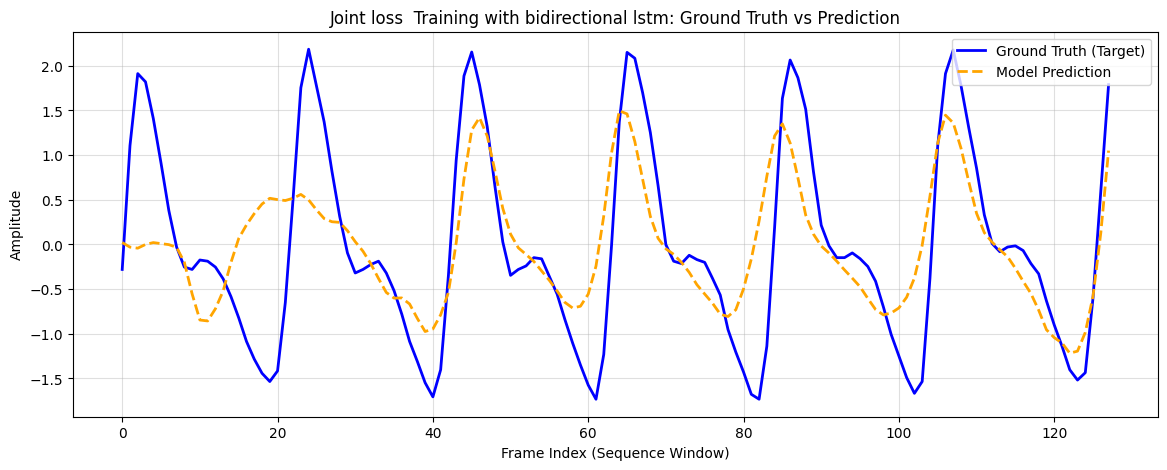

In [17]:
import matplotlib.pyplot as plt


preds, sign = test(model)


preds_np = preds.detach().cpu().numpy()
preds_np = preds_np
sign_np = sign.detach().cpu().numpy()

plt.figure(figsize=(14, 5))


plt.plot(sign_np, label='Ground Truth (Target)', color='blue', linewidth=2)
plt.plot(preds_np, label='Model Prediction', color='orange', linewidth=2, linestyle='--')

plt.title('Joint loss  Training with bidirectional lstm: Ground Truth vs Prediction')
plt.xlabel('Frame Index (Sequence Window)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig('joint_loss_version.png')
# Show the plot
plt.show()

In [23]:
#Ignore early frames because they are inherently unpredictable but they are making it hard for the model to learn the pattern of the signal because they still send gradients  and the model is trying to learn them

check_point_pth = os.path.join('checkpoints', 'joint_loss_bidrec_with_skip_early_frames.pth')
prev_best_val_loss = float('inf')


log_every = 10
num_epochs = 10 
val_every = 100


def save_checkpoint(model, optimizer, epoch, step, loss, path):
    checkpoint = {
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'epoch':epoch,
        'step':step,
        'loss':loss
    }
    torch.save(checkpoint, path)

model = LSTMModel(input_size=9, hidden_size=64, num_layers=2, output_size=1)


model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

if os.path.exists(check_point_pth):
    checkpoint = torch.load(check_point_pth)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    

In [24]:

for epoch in range(num_epochs):
    model.train()
    total_loss = 0  
    for i, (color_seq, signal_seq) in enumerate(train_loader):
        optimizer.zero_grad()
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq) 
        #mask the first 60 frames  
        predictions = predictions[60:]
        signal_seq = signal_seq[60:]
        pearson_loss,mse_loss,loss = criterion(predictions.flatten(), signal_seq.flatten())
        loss.backward()
        optimizer.step() 
        if (i+1) % log_every == 0:    
            if (i+1) % val_every ==0:
                val_loss = val()
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], train Loss: {loss.item():.4f}, val Loss: {val_loss:.4f}") 
                if val_loss < prev_best_val_loss:
                    print(f"New best model 💫💫 found.   loss: {val_loss:.4f}")  
                    save_checkpoint(model, optimizer, epoch, i, val_loss, check_point_pth)
                    prev_best_val_loss = val_loss
            else: 
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Pearson train Loss: {pearson_loss.item():.4f} MSE train Loss: {mse_loss.item():.4f}")

Epoch [1/10], Step [10/238], Pearson train Loss: 0.6878 MSE train Loss: 1.0612
Epoch [1/10], Step [20/238], Pearson train Loss: 0.6078 MSE train Loss: 1.0061
Epoch [1/10], Step [30/238], Pearson train Loss: 0.5854 MSE train Loss: 0.9274
Epoch [1/10], Step [40/238], Pearson train Loss: 0.4963 MSE train Loss: 0.9832
Epoch [1/10], Step [50/238], Pearson train Loss: 0.4234 MSE train Loss: 1.0108
Epoch [1/10], Step [60/238], Pearson train Loss: 0.4117 MSE train Loss: 0.9711
Epoch [1/10], Step [70/238], Pearson train Loss: 0.4316 MSE train Loss: 0.9602
Epoch [1/10], Step [80/238], Pearson train Loss: 0.4056 MSE train Loss: 0.9716
Epoch [1/10], Step [90/238], Pearson train Loss: 0.4102 MSE train Loss: 1.0097
Epoch [1/10], Step [100/238], train Loss: 1.4251, val Loss: 1.4150
New best model 💫💫 found.   loss: 1.4150
Epoch [1/10], Step [110/238], Pearson train Loss: 0.4126 MSE train Loss: 0.9899
Epoch [1/10], Step [120/238], Pearson train Loss: 0.3998 MSE train Loss: 0.9957
Epoch [1/10], Step [13

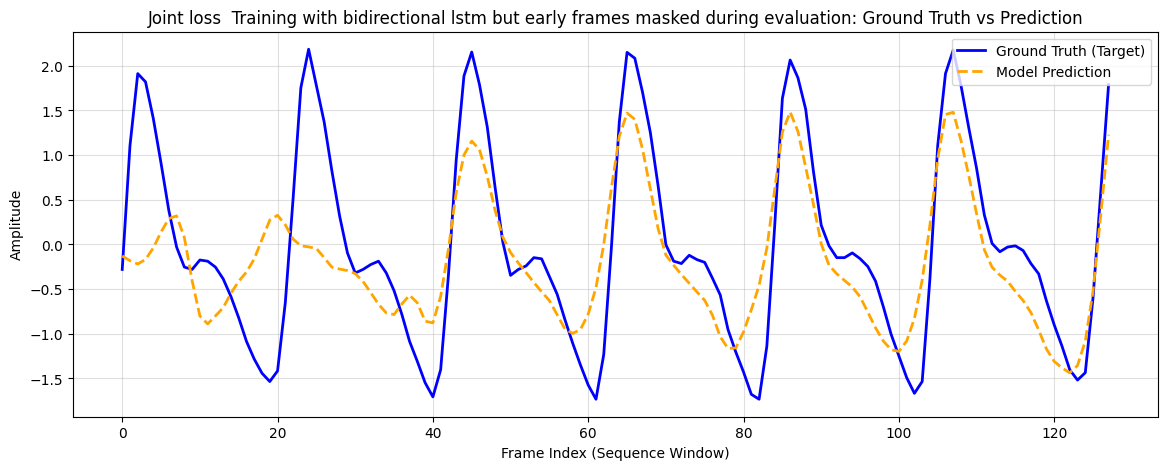

In [25]:
import matplotlib.pyplot as plt


preds, sign = test(model)
preds_np = preds.detach().cpu().numpy()
preds_np = preds_np
sign_np = sign.detach().cpu().numpy()

plt.figure(figsize=(14, 5))
plt.plot(sign_np, label='Ground Truth (Target)', color='blue', linewidth=2)
plt.plot(preds_np, label='Model Prediction', color='orange', linewidth=2, linestyle='--')

plt.title('Joint loss  Training with bidirectional lstm but early frames masked during evaluation: Ground Truth vs Prediction')
plt.xlabel('Frame Index (Sequence Window)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig('joint_loss_version_with_masked_frames.png')
# Show the plot
plt.show()

In [29]:
#ignoring early frames yielded better alignment with better alignment but mse should have low impact on the loss now because its causing smoothing of the signal and the model is not learning teh pattern of the signal

#next experiment: use weighted loss where pearson loss has a higher loss

check_point_pth = os.path.join('checkpoints', 'joint_loss_bidrec_with_skip_early_frames_and_weighted_loss.pth')
prev_best_val_loss = float('inf')


log_every = 10
num_epochs = 10 
val_every = 100


def save_checkpoint(model, optimizer, epoch, step, loss, path):
    checkpoint = {
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'epoch':epoch,
        'step':step,
        'loss':loss
    }
    torch.save(checkpoint, path)

model = LSTMModel(input_size=9, hidden_size=64, num_layers=2, output_size=1)


model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

if os.path.exists(check_point_pth):
    checkpoint = torch.load(check_point_pth)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    

In [32]:


class HybridWeightedRPPGLoss(torch.nn.Module):
    def forward(self, preds, target,alpha=0.2):
        preds = preds - torch.mean(preds)
        target = target - torch.mean(target)
        numerator = torch.sum(preds * target)
        denominator = torch.sqrt(torch.sum(preds ** 2)) * torch.sqrt(torch.sum(target ** 2))
        pearson_corr = numerator / (denominator + 1e-8)
        pearson_loss = 1 - pearson_corr


        mse = torch.nn.MSELoss()
        mse_loss = mse(preds,target)
        return  pearson_loss,mse_loss, (1-alpha)*pearson_loss + alpha * mse_loss

criterion = HybridWeightedRPPGLoss()


for epoch in range(num_epochs):
    model.train()
    total_loss = 0  
    for i, (color_seq, signal_seq) in enumerate(train_loader):
        optimizer.zero_grad()
        color_seq = color_seq.to(device)
        signal_seq = signal_seq.to(device)
        predictions = model(color_seq) 
        #mask the first 60 frames  
        predictions = predictions[60:]
        signal_seq = signal_seq[60:]
        pearson_loss,mse_loss,loss = criterion(predictions.flatten(), signal_seq.flatten())
        loss.backward()
        optimizer.step() 
        if (i+1) % log_every == 0:    
            if (i+1) % val_every ==0:
                val_loss = val()
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], train Loss: {loss.item():.4f}, val Loss: {val_loss:.4f}") 
                if val_loss < prev_best_val_loss:
                    print(f"New best model 💫💫 found.   loss: {val_loss:.4f}")  
                    save_checkpoint(model, optimizer, epoch, i, val_loss, check_point_pth)
                    prev_best_val_loss = val_loss
            else: 
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Pearson train Loss: {pearson_loss.item():.4f} MSE train Loss: {mse_loss.item():.4f}")

Epoch [1/10], Step [10/238], Pearson train Loss: 0.2443 MSE train Loss: 0.4319
Epoch [1/10], Step [20/238], Pearson train Loss: 0.2473 MSE train Loss: 0.4502
Epoch [1/10], Step [30/238], Pearson train Loss: 0.2454 MSE train Loss: 0.4386
Epoch [1/10], Step [40/238], Pearson train Loss: 0.2689 MSE train Loss: 0.4505
Epoch [1/10], Step [50/238], Pearson train Loss: 0.2490 MSE train Loss: 0.4207
Epoch [1/10], Step [60/238], Pearson train Loss: 0.2601 MSE train Loss: 0.4793
Epoch [1/10], Step [70/238], Pearson train Loss: 0.2463 MSE train Loss: 0.4587
Epoch [1/10], Step [80/238], Pearson train Loss: 0.2399 MSE train Loss: 0.4325
Epoch [1/10], Step [90/238], Pearson train Loss: 0.2325 MSE train Loss: 0.4144
Epoch [1/10], Step [100/238], train Loss: 0.2905, val Loss: 0.2953
New best model 💫💫 found.   loss: 0.2953
Epoch [1/10], Step [110/238], Pearson train Loss: 0.2430 MSE train Loss: 0.4391
Epoch [1/10], Step [120/238], Pearson train Loss: 0.2573 MSE train Loss: 0.4615
Epoch [1/10], Step [13

KeyboardInterrupt: 

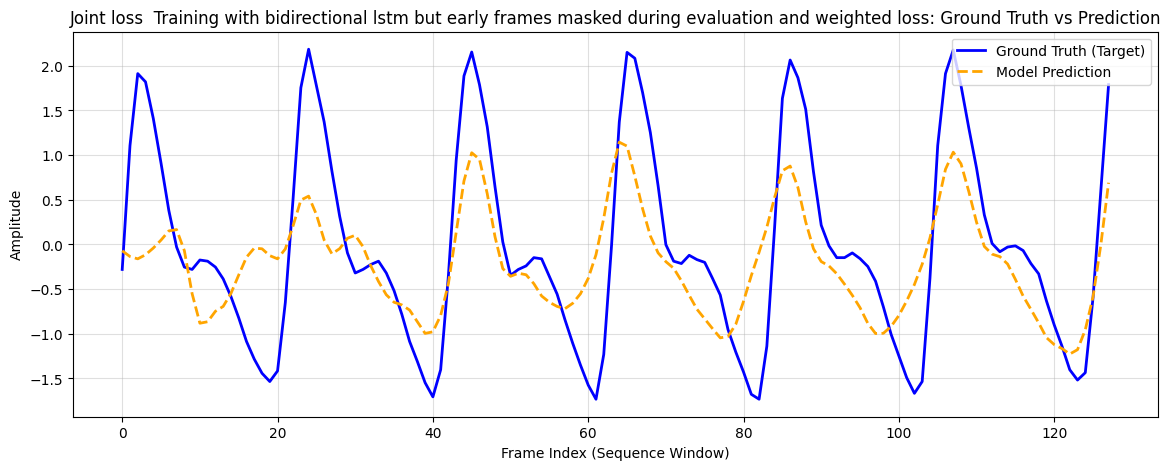

In [33]:
import matplotlib.pyplot as plt


preds, sign = test(model)
preds_np = preds.detach().cpu().numpy()
preds_np = preds_np
sign_np = sign.detach().cpu().numpy()

plt.figure(figsize=(14, 5))
plt.plot(sign_np, label='Ground Truth (Target)', color='blue', linewidth=2)
plt.plot(preds_np, label='Model Prediction', color='orange', linewidth=2, linestyle='--')

plt.title('Joint loss  Training with bidirectional lstm but early frames masked during evaluation and weighted loss: Ground Truth vs Prediction')
plt.xlabel('Frame Index (Sequence Window)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig('joint_loss_version_with_masked_frames_and_weighted_loss.png')
# Show the plot
plt.show()